# Example Figures

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
resultsDir = '/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Results/Group'
saveDir = '/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Presentations/Methods Figures'

statsDF = pd.read_csv(os.path.join(resultsDir, 'SpikeStats.csv'), index_col = 0)
allSpikeInfo = pd.read_csv(os.path.join(resultsDir, 'AllSpikeInfo.csv'), index_col = 0)

fs = 30000

## Example Permutation Test
UIC20230201, mROFC8-1

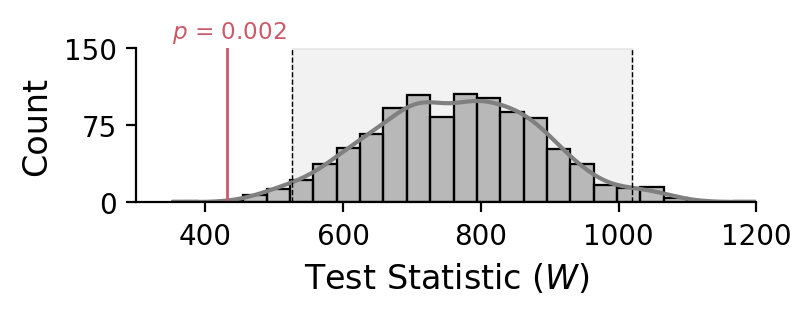

In [13]:
# Get sample unit
pID = 'UIC20230201'
unit = 'mROFC8-1'

sampleInfo = allSpikeInfo[(allSpikeInfo['Unit'] == unit)].copy()
sample = statsDF[(statsDF['Unit'] == unit)].copy()
permStats = sample['PermStats_PrePost'].values[0]
stat = sample['Stat_PrePost'].values[0]
pVal = sample['pVal_PrePost'].values[0]

# Convert permStats to list
permStats = permStats[1:-1]
permStats = permStats.split(', ')
permStats = [float(i) for i in permStats]
permStats = np.array(permStats)

# Create figure
fig, ax = plt.subplots(1, 1, figsize = (4, 1))
plotPal = ['#e6e6e6', sns.color_palette('flare')[5]]
sns.histplot(permStats, color = 'grey', ax = ax, kde = True, label = None)
ax.axvline(stat, color = '#cb5967', linestyle = '-', lw = 1, label = None)
ax.axvline(np.quantile(permStats, .025), color = 'k', linestyle = '--', lw = 0.5, label = None)
ax.axvline(np.quantile(permStats, .975), color = 'k', linestyle = '--', lw = 0.5, label = None)
ax.axvspan(np.quantile(permStats, .025), np.quantile(permStats, .975), color = 'grey', alpha = 0.1, zorder = -1, label = None)
ax.text(stat - 80, 160, f'$p$ = {pVal:.3f}', fontsize = 'small', color = '#cb5967')

# Figure aeshtetics
ax.set_xlabel('Test Statistic ($W$)', fontsize = 'large')
ax.set_ylabel('Count', fontsize = 'large')
ax.set_ylim(0, 150)
ax.set_yticks([0, 75, 150])
ax.set_xlim(300, 1200)
sns.despine(top = True, right = True)

# Export & Display
plt.savefig((os.path.join(resultsDir, 'Figures', 'PermSigEx.pdf')), dpi = 1200, bbox_inches = 'tight')
plt.show()

## Example Counts

In [4]:
trial_counts = pd.read_csv('/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Results/UIC20230201/TrialSpikeCounts.csv', index_col = 0)
trial_counts = trial_counts[(trial_counts['Unit'] == unit) & (trial_counts['Condition'] == 'Stim')].copy().reset_index(drop = True)
trial_counts = trial_counts[['Pre', 'Post']]
trial_counts = trial_counts.melt(var_name = 'Epoch', value_name = 'Spikes')
pre_counts = trial_counts[trial_counts['Epoch'] == 'Pre']['Spikes'].values
post_counts = trial_counts[trial_counts['Epoch'] == 'Post']['Spikes'].values
diff_counts = post_counts - pre_counts

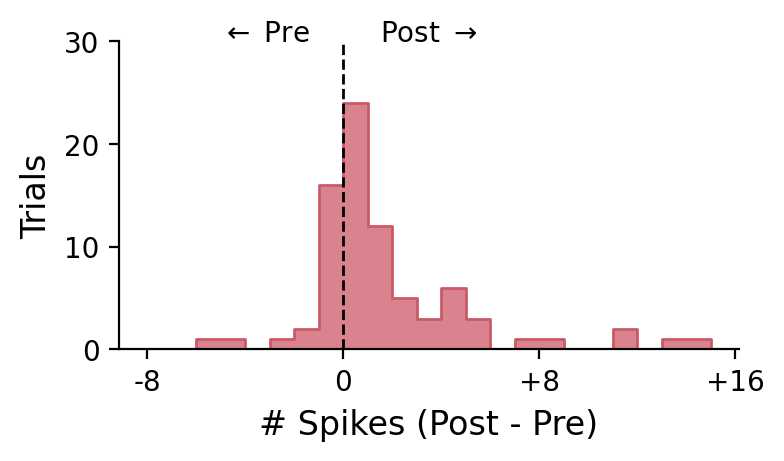

In [5]:
fig, ax = plt.subplots(1, 1, figsize = (4, 2), sharey = True)
plotPal = [sns.color_palette('flare')[5]]
sns.histplot(diff_counts, color = '#cb5967', ax = ax, label = None, element = 'step', kde = False, bins = np.arange(-8, 16, 1))
plt.axvline(0, color = 'k', linestyle = '--', lw = 1, label = None)
plt.text(-5, 30, '$\\leftarrow$ Pre', fontsize = 'medium', color = 'k')
plt.text(1.5, 30, 'Post $\\rightarrow$', fontsize = 'medium', color = 'k')

# Figure aeshtetics
sns.despine(top = True, right = True)
plt.xticks(np.arange(-8, 17, 8), ['-8', '0', '+8', '+16'])
plt.yticks(np.arange(0, 31, 10))
plt.ylabel('Trials', fontsize = 'large')
plt.xlabel('# Spikes (Post - Pre)', fontsize = 'large')

# Export & Display
plt.savefig((os.path.join(resultsDir, 'Figures', 'TrialSpikeDiffs.pdf')), dpi = 1200, bbox_inches = 'tight')
plt.show()

# Theta Burst Stimulation

In [6]:
def simulateStim(gamma = 50, amp = 1, n_bursts = 8, PW = 250, AC_IPI = 53, DC = 0.5, savestr = None):
    '''
    Simulate a BLAES signal with the given parameters.
    
    Inputs:
    - gamma (int): the gamma-frequency component of stim (Hz); determines the inter-pulse interval [default = 50]
    - amp (int): the amplitude of the signal (mA) [default = 1]
    - n_bursts (int): the number of bursts (theta component) [default = 8]
    - PW (int): the pulse width (us) [default = 250]
    - AC_IPI (int): the anode-cathode inter-pulse interval (us) [default = 53]
    - DC (float): the duty cycle (on/off time ratio) [default = 0.5]
    - savestr (str): the path to save the figure [default = None]
    
    Outputs:
    - None (optional export of figure to path specified by savestr)
    '''
    
    # Set the parameters
    samples = 1e6                                                           # number of samples / us
    burst_duration = int((1 / n_bursts) * DC * samples)                     # burst duration (samples / us)
    IPI = int(1 / gamma * samples) - (PW*2) - AC_IPI                        # inter-pulse interval (samples / us)
    last_pulse = np.arange(0, burst_duration+1, IPI)[-1]                    # last pulse in the burst (samples / us)
    IBI = (burst_duration * 2) - last_pulse - (PW*2) - AC_IPI               # inter-burst interval (samples / us)

    # Initialize the signal
    t = np.arange(0, 1, 1/samples) # time vector (s)
    x = np.zeros_like(t) # signal vector

    # Simulate stimulation
    for i in range(0, len(t), int(1 / n_bursts * samples)):
        for j in np.arange(0, burst_duration+1, IPI):
            x[i+j:i+j+PW] = amp
            x[i+j+PW+AC_IPI:i+j+PW+AC_IPI+PW] = -amp

    # Figure parameters
    fig, ax = plt.subplots(figsize=(6, 2))

    # Plotting
    plt.plot(t, x, color = sns.color_palette('flare')[5])

    # Figure aeshetics
    plt.xlabel('Time (ms)')
    plt.xticks(np.arange(0, 1.25, 0.25), np.arange(0, 1250, 250))
    plt.xlim(-0.025, 1.025)
    plt.ylabel('Amplitude (mA)')
    plt.yticks([-1, 0, 1])
    plt.ylim(-1.5, 1.5)
    sns.despine(top = True, right = True)
    
    # Export
    plt.savefig('/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Presentations/Methods Figures/TBSEx.pdf', bbox_inches = 'tight', dpi = 1200)

In [7]:
def simulatePulse(PW = 250, AC_IPI = 53, save = False):
    '''
    Simulate a single pulse with the given parameters.
    
    Inputs:
    - PW (int): the pulse width (us) [default = 250]
    - AC_IPI (int): the anode-cathode inter-pulse interval (us) [default = 53]
    - save (bool): whether to save the figure [default = False]
    
    Outputs:
    - None
    '''
    
    # Set the parameters
    t = np.arange(0, 1500) # time vector (s)
    t_start = 250
    x = np.zeros_like(t) # signal vector

    # Simulate stimulation
    x[t_start:t_start+PW] = 1
    x[t_start+PW+AC_IPI:t_start+PW+AC_IPI+PW] = -1

    # Figure parameters
    fig, ax = plt.subplots(figsize=(3, 2))

    # Plotting
    plt.plot(t, -x/2, color = sns.color_palette('flare')[5], linestyle = '--', lw = 1)
    plt.plot(t, -x, color = sns.color_palette('flare')[5])
    plt.plot(t, x/2, color = '#e4e4e4', linestyle = '--', lw = 1, zorder = -1)
    plt.plot(t, x, color = '#e4e4e4', zorder = -1)

    # Figure aeshetics
    plt.xlabel('Time (ms)')
    plt.xticks(np.arange(0, 1001, 250), (np.arange(0, 1001, 250)-250)/1000)
    plt.xlim(0, 1000)
    plt.ylabel('Amplitude (mA)')
    plt.yticks([-1, 0, 1])
    plt.ylim(-1.5, 1.5)
    # plt.legend(bbox_to_anchor=(1.4,1.05), title = 'Bipolar TBS', fontsize = 'x-small', title_fontsize = 'small')
    sns.despine(top = True, right = True)
    
    # Export
    plt.savefig('/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Presentations/Methods Figures/BipolarPulseEx.pdf', bbox_inches = 'tight', dpi = 1200)

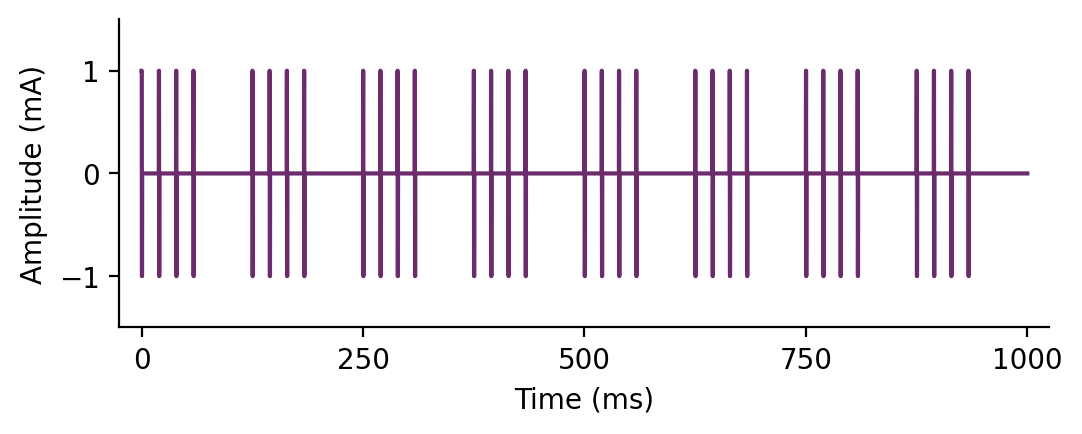

In [8]:
simulateStim()

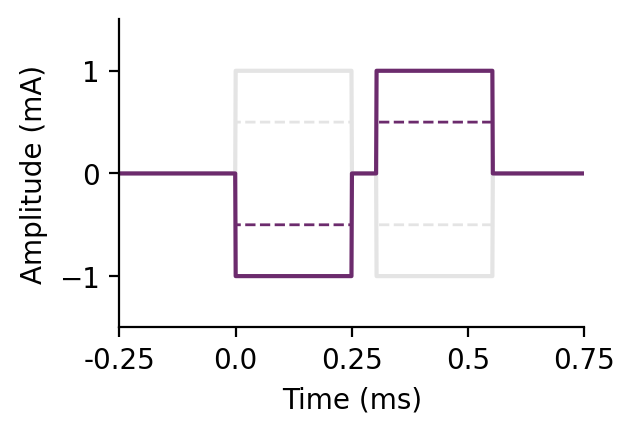

In [9]:
simulatePulse()